# A. Cel ćwiczenia

Celem niniejszego ćwiczenia jest praktyczna implementacja oraz ewaluacja skuteczności sztucznych sieci neuronowych, w szczególności modelu perceptrona wielowarstwowego (MLP – Multi-Layer Perceptron), w procesie aproksymacji nieliniowych zależności zachodzących pomiędzy składem chemicznym betonu a jego wytrzymałością na ściskanie.

# B. Część teoretyczna

## Podstawy modelu wielowarstwowego perceptronu (MLP) w regresji

Wielowarstwowy perceptron (ang. *Multilayer Perceptron*, MLP) to rodzaj sztucznej sieci neuronowej o strukturze jednokierunkowej (*feedforward*). Zgodnie z twierdzeniem o uniwersalnej aproksymacji, sieć z co najmniej jedną warstwą ukrytą i nieliniową funkcją aktywacji może przybliżać dowolną ciągłą funkcję, jeśli ma odpowiednią liczbę neuronów. Dzięki temu MLP dobrze sprawdza się w zadaniach regresji, gdzie celem jest przewidywanie wartości ciągłych.

### 1. Architektura i propagacja w przód

Sieć MLP składa się z warstwy wejściowej, jednej lub kilku warstw ukrytych oraz warstwy wyjściowej. Dane przepływają od wejścia do wyjścia.

Dla warstwy ukrytej $ l \$ obliczenia mają postać:

$$
\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}, \quad
\mathbf{h}^{(l)} = \sigma^{(l)}(\mathbf{z}^{(l)})
$$

gdzie:

$$
\mathbf{W}^{(l)} \text{ – macierz wag}, \quad
\mathbf{b}^{(l)} \text{ – wektor biasów}, \quad
\sigma \text{ – funkcja aktywacji (np. ReLU: } \max(0, z) \text{)}
$$
### 2. Warstwa wyjściowa w regresji

W regresji warstwa wyjściowa ma zwykle jeden neuron (lub więcej przy wielu zmiennych wyjściowych) i używa funkcji liniowej. Dzięki temu model może przewidywać dowolne wartości rzeczywiste:

$$
\hat{y} = \mathbf{w}^{(out)\top} \mathbf{h}^{(L)} + b^{(out)}
$$

### 3. Funkcja kosztu

Do uczenia modelu najczęściej stosuje się błąd średniokwadratowy (MSE):

$$
J(\Theta) = \frac{1}{2N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2 + \frac{\alpha}{2} \sum |\mathbf{W}^{(l)}|^2
$$

Drugi składnik to regularyzacja L2, która ogranicza zbyt duże wartości wag i pomaga zmniejszyć przeuczenie.

### 4. Uczenie modelu

Parametry sieci są optymalizowane metodami opartymi na spadku gradientu. Gradienty oblicza się przy użyciu algorytmu wstecznej propagacji błędu (*backpropagation*).

Aktualizacja wag ma postać:

$$
w \leftarrow w - \eta \frac{\partial J}{\partial w}
$$

gdzie $\eta$ to współczynnik uczenia. W praktyce często stosuje się bardziej zaawansowane metody, takie jak Adam, które automatycznie dostosowują tempo uczenia i przyspieszają zbieżność.

## Rola nieliniowych funkcji aktywacji ze szczególnym uwzględnieniem ReLU

W architekturze wielowarstwowego perceptronu (MLP) funkcje aktywacji umożliwiają modelowanie nieliniowych zależności. Dla każdego neuronu sygnał wejściowy $z$ obliczany jest jako:

$$z = \mathbf{w}^\top \mathbf{x} + b$$

Bez funkcji aktywacji sieć byłaby matematycznie równoważna jednowarstwowej regresji liniowej. Aby temu zapobiec, stosuje się nieliniową funkcję $\sigma(\cdot)$, dając wyjście neuronu $a = \sigma(z)$.

### 1. Funkcja ReLU

Współczesnym standardem dla warstw ukrytych jest **ReLU** (Rectified Linear Unit):

$$\text{ReLU}(z) = \max(0, z)$$

Jej pochodna (gradient w propagacji wstecznej) ma postać:

$$\frac{d}{dz}\text{ReLU}(z) = \begin{cases} 1 & z > 0 \\ 0 & z \le 0 \end{cases}$$

**Zalety nad funkcjami sigmoidalnymi:**
- **Brak zanikającego gradientu** — stała pochodna $1$ na dodatniej półosi pozwala gradientowi swobodnie przepływać przez głębokie warstwy.
- **Efektywność obliczeniowa** — wystarczy jedna operacja porównania, bez potęgowania.
- **Rzadkość reprezentacji** — zerowanie ujemnych aktywacji sprawia, że tylko część neuronów jest aktywna, co ogranicza overfitting.

**Ograniczenie — problem martwych neuronów (*Dying ReLU*):** jeśli neuron zacznie generować wyłącznie ujemne wartości $z$, jego gradient trwale osiągnie zero i wagi przestaną być aktualizowane.

## Algorytmy optymalizacji wag: Algorytm Adam (Adaptive Moment Estimation)

Uczenie MLP sprowadza się do minimalizacji funkcji kosztu $J(\Theta)$ względem wektora parametrów $\Theta$. Ze względu na wysoce nieliniowy i niekonweksowy charakter hiperpowierzchni błędu, rozwiązanie analityczne jest niemożliwe — stosuje się iteracyjne metody gradientowe.


### 1. Ograniczenia klasycznego SGD

Klasyczny stochastyczny spadek gradientu aktualizuje parametry według reguły:

$$\Theta_{t} = \Theta_{t-1} - \eta \, \mathbf{g}_t$$

gdzie $\mathbf{g}_t = \nabla_{\Theta} J(\Theta_{t-1})$ to gradient w kroku $t$, a $\eta$ to globalny współczynnik uczenia. SGD napotyka trudności w otoczeniu punktów siodłowych oraz w wąwozach hiperpowierzchni (duża różnica krzywizny między wymiarami). Ponadto globalny, jednakowy dla wszystkich parametrów $\eta$ powoduje, że rzadkie i częste cechy ewoluują w tym samym tempie.


### 2. Algorytm Adam — podstawy

**Adam** łączy zalety dwóch rozszerzeń SGD:
- **Momentum** — przyspiesza zbieżność, tłumiąc oscylacje,
- **RMSProp** — skaluje krok uczenia odwrotnie proporcjonalnie do historycznych gradientów.

Adam estymuje **pierwszy moment** (średnia gradientów) i **drugi moment** (niecentrowana wariancja) za pomocą wykładniczych średnich ruchomych:

$$\mathbf{m}_t = \beta_1 \mathbf{m}_{t-1} + (1 - \beta_1)\, \mathbf{g}_t$$
$$\mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2)\, \mathbf{g}_t^2$$

gdzie $\beta_1, \beta_2 \in [0,1)$ to współczynniki zaniku historii (standardowo $\beta_1 = 0{,}9$, $\beta_2 = 0{,}999$).


### 3. Korekta obciążenia estymatorów

Ponieważ $\mathbf{m}_0 = \mathbf{v}_0 = \mathbf{0}$, estymatory są w początkowych iteracjach obciążone w kierunku zera. Adam wprowadza korektę:

$$\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1 - \beta_1^t}, \qquad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_2^t}$$

Mianowniki $1 - \beta_1^t$ i $1 - \beta_2^t$ asymptotycznie dążą do $1$ w miarę wzrostu $t$, przez co wpływ korekty naturalnie zanika w późniejszych fazach uczenia.


### 4. Reguła aktualizacji wag

Ostateczna aktualizacja parametrów przyjmuje postać:

$$\Theta_{t} = \Theta_{t-1} - \frac{\eta}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon}\, \hat{\mathbf{m}}_t$$

gdzie:
- $\eta$ — bazowy współczynnik uczenia,
- $\epsilon \approx 10^{-8}$ — stała stabilności numerycznej (zapobiega dzieleniu przez zero).

Wszystkie operacje w mianowniku wykonywane są **element po elemencie**, co oznacza że każdy parametr posiada indywidualny, adaptacyjny krok uczenia.

## Ewaluacja modeli regresyjnych: Metryki błędu i dopasowania

Niech zbiór testowy składa się z $N$ obserwacji, gdzie $y_i$ to wartość rzeczywista, $\hat{y}_i$ — predykcja modelu, a $\bar{y} = \frac{1}{N}\sum_{i=1}^N y_i$ — średnia arytmetyczna wartości rzeczywistych.


#### 1. Błąd średniokwadratowy (Mean Squared Error – MSE)

$$MSE = \frac{1}{N} \sum_{i=1}^{N} \left( y_i - \hat{y}_i \right)^2$$

MSE stanowi empiryczne przybliżenie wariancji błędu modelu. Dzięki **kwadratowej penalizacji** błędów obserwacje odstające (*outliers*) mają nieproporcjonalnie duży wpływ na wynik — metryka jest zatem wrażliwa na wartości skrajne. Z perspektywy optymalizacyjnej MSE jest funkcją ściśle wypukłą i różniczkowalną w całej dziedzinie, co czyni ją standardowym wyborem jako funkcję straty w algorytmach gradientowych. Jednostką MSE jest **kwadrat jednostki** zmiennej objaśnianej, co utrudnia bezpośrednią interpretację.


#### 2. Średni błąd bezwzględny (Mean Absolute Error – MAE)

$$MAE = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

MAE nakłada na błędy predykcji karę **liniową**, dzięki czemu jest znacznie bardziej odporna na wartości odstające niż MSE. Wynik wyrażony jest w tych samych jednostkach co zmienna objaśniana $y$, co zapewnia intuicyjną interpretację: wskazuje, o ile jednostek średnio myli się model. Wadą jest nieróżniczkowalność w punkcie zero, co wymaga stosowania subgradientów przy bezpośredniej optymalizacji tej metryki.


#### 3. Współczynnik determinacji ($R^2$ Score)

Współczynnik determinacji określa, jaka proporcja wariancji zmiennej objaśnianej została wyjaśniona przez model. Obliczany jest jako stosunek sumy kwadratów reszt (RSS) do całkowitej sumy kwadratów (TSS):

$$R^2 = 1 - \frac{\sum_{i=1}^{N}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{N}(y_i - \bar{y})^2}$$

Miara $R^2$ przyjmuje wartości z przedziału $(-\infty, 1]$:
- $R^2 = 1$ — idealne dopasowanie modelu (brak błędów predykcji),
- $R^2 = 0$ — model równoważny trywialnemu estymatorowi przewidującemu stale $\bar{y}$,
- $R^2 < 0$ — model gorszy od naiwnej średniej, co zwykle świadczy o błędnej specyfikacji architektury.

Kluczową zaletą $R^2$ jest **niezależność od skali i jednostek**, co umożliwia obiektywne porównywanie modeli na różnych zbiorach danych.

## Optymalizacja hiperparametrów: Grid Search i walidacja krzyżowa

W modelach uczenia maszynowego rozróżniamy **parametry** (wagi $\mathbf{W}$, obciążenia $\mathbf{b}$ — estymowane gradientowo z danych) oraz **hiperparametry** (liczba warstw, liczba neuronów, $\eta$, $\alpha$ — definiowane *a priori*, nie podlegają bezpośredniej optymalizacji). Proces poszukiwania optymalnej konfiguracji hiperparametrów minimalizującej błąd generalizacji nazywamy **strojeniem hiperparametrów**.


#### 1. Formalizacja problemu

Niech $\lambda \in \Lambda$ oznacza wektor hiperparametrów, a $\mathcal{A}(D_{train}, \lambda)$ — model wyindukowany przez algorytm uczący na zbiorze $D_{train}$. Celem jest znalezienie:

$$\lambda^* = \arg\min_{\lambda \in \Lambda} \, \mathcal{L}\!\left(\mathcal{A}(D_{train}, \lambda),\, D_{val}\right)$$

gdzie $\mathcal{L}$ to wybrana funkcja strat, a $D_{val}$ — zbiór walidacyjny.


#### 2. Przeszukiwanie siatki (Grid Search)

Grid Search to deterministyczna, wyczerpująca metoda przeglądu przestrzeni hiperparametrów. Definiujemy skończony zbiór wartości dla każdego z $M$ hiperparametrów, a przestrzeń przeszukiwań stanowi ich iloczyn kartezjański:

$$\Lambda_{grid} = \Lambda_1 \times \Lambda_2 \times \dots \times \Lambda_M$$

Algorytm (np. GridSearchCV w scikit-learn) iteruje przez każdą kombinację $\lambda \in \Lambda_{grid}$, trenując i oceniając model dla każdej konfiguracji.


#### 3. Walidacja krzyżowa ($k$-fold Cross-Validation)

Aby estymacja błędu była wiarygodna i odporna na konkretny podział danych, ocenę integruje się z $k$-krotną walidacją krzyżową:

1. Zbiór $\mathcal{D}$ dzielony jest na $K$ rozłącznych podzbiorów (fałd): $\mathcal{D} = \bigcup_{k=1}^K D_k$.
2. Model jest trenowany $K$-krotnie — w $k$-tej iteracji zbiorem walidacyjnym jest $D_k$, a uczącym $\mathcal{D} \setminus D_k$.
3. Błąd walidacji krzyżowej obliczany jest jako średnia z wszystkich $K$ iteracji:

$$E_{CV}(\lambda) = \frac{1}{K} \sum_{k=1}^{K} \mathcal{L}\!\left(\mathcal{A}(\mathcal{D} \setminus D_k,\, \lambda),\, D_k\right)$$

Walidacja krzyżowa minimalizuje wariancję estymatora błędu generalizacji, dostarczając bezstronnej i stabilnej oceny modelu.


#### 4. Mechanizm decyzyjny i refit

Po przetestowaniu wszystkich konfiguracji algorytm wskazuje optymalny wektor hiperparametrów:

$$\hat{\lambda}^* = \arg\min_{\lambda \in \Lambda_{grid}} E_{CV}(\lambda)$$

Następnie GridSearchCV automatycznie przetrenowuje (*refit*) model z $\hat{\lambda}^*$ na **całym** zbiorze $\mathcal{D}$, maksymalizując ilość informacji dostępnych przed predykcją na zbiorze testowym.


#### 5. Złożoność obliczeniowa

Łączna liczba trenowanych modeli wynosi:

$$N_{models} = K \cdot \prod_{m=1}^{M} |\Lambda_m|$$

Złożoność rośnie **wykładniczo** wraz z liczbą hiperparametrów — jest to tzw. *przekleństwo wymiarowości*. Dla dużych przestrzeni przeszukiwań stosuje się metody stochastyczne (Random Search) lub optymalizację bayesowską. Dla mniejszych sieci i ograniczonej liczby hiperparametrów Grid Search pozostaje standardem zapewniającym wyczerpujące zbadanie zdefiniowanej podprzestrzeni.

# C. Raport

1. zadanie: Zaimportuj niezbędne moduły.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error

2. zadanie: Wczytaj dane, dokonaj selekcji danych – każdy student tworzy inny zbiór danych, który składa się z 1000
wylosowanych wierszy danych oryginalnych (skorzystaj z kodu zamieszczonego w ćwiczeniu dot. drzew
decyzyjnych).

In [ ]:
data = pd.read_csv("Concrete_Data_Yeh.csv")
nr_gr = 5.1
r_k = 2026
np.random.seed(int(nr_gr*r_k))
q = data.shape
idx = np.random.permutation(q[0])
data = data.iloc[idx[0:1000],:]
data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
64,266.0,114.0,0.0,228.0,0.0,932.0,670.0,180,48.70
902,331.0,170.0,0.0,195.0,8.0,811.0,802.0,28,56.61
43,380.0,0.0,0.0,228.0,0.0,932.0,670.0,180,53.10
262,212.6,0.0,100.4,159.4,10.4,1003.8,903.8,56,44.40
692,212.0,141.3,0.0,203.5,0.0,973.4,750.0,90,39.70


3. zadanie: Sprawdź czy w danych są zduplikowane wiersze i brakujące wartości. Jeśli tak, usuń te wiersze (data =
data.drop_duplicates()).

In [ ]:
duplikaty = data.duplicated().sum()
print(f"Liczba duplikatów: ",duplikaty)
data = data.drop_duplicates()
braki = data.isnull().sum()
print(f"brakujące wartości: \n",braki)

Liczba duplikatów:  25
brakujące wartości: 
 cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64


4. zadanie: Scharakteryzuj dane, (przydatne funkcje: data.describe(), data.info()), zobrazuj powiązania
pomiędzy zmiennymi i ich rozkłady (sns.pairplot()) oraz korelacje pomiędzy zmiennymi.

In [ ]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
Index: 975 entries, 64 to 90
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            975 non-null    float64
 1   slag              975 non-null    float64
 2   flyash            975 non-null    float64
 3   water             975 non-null    float64
 4   superplasticizer  975 non-null    float64
 5   coarseaggregate   975 non-null    float64
 6   fineaggregate     975 non-null    float64
 7   age               975 non-null    int64  
 8   csMPa             975 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 76.2 KB


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000,975.000000
mean,279.794256,72.267077,54.617026,182.011487,6.022462,974.535282,772.777436,45.936410,35.284862
std,104.727280,86.336458,63.959262,21.365035,5.938608,78.168390,80.526530,64.091391,16.265481
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.000000,0.000000,0.000000,166.600000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,266.000000,20.000000,0.000000,185.700000,6.000000,968.000000,780.000000,28.000000,33.800000
75%,349.000000,142.500000,118.300000,192.350000,10.000000,1039.000000,823.100000,56.000000,45.080000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


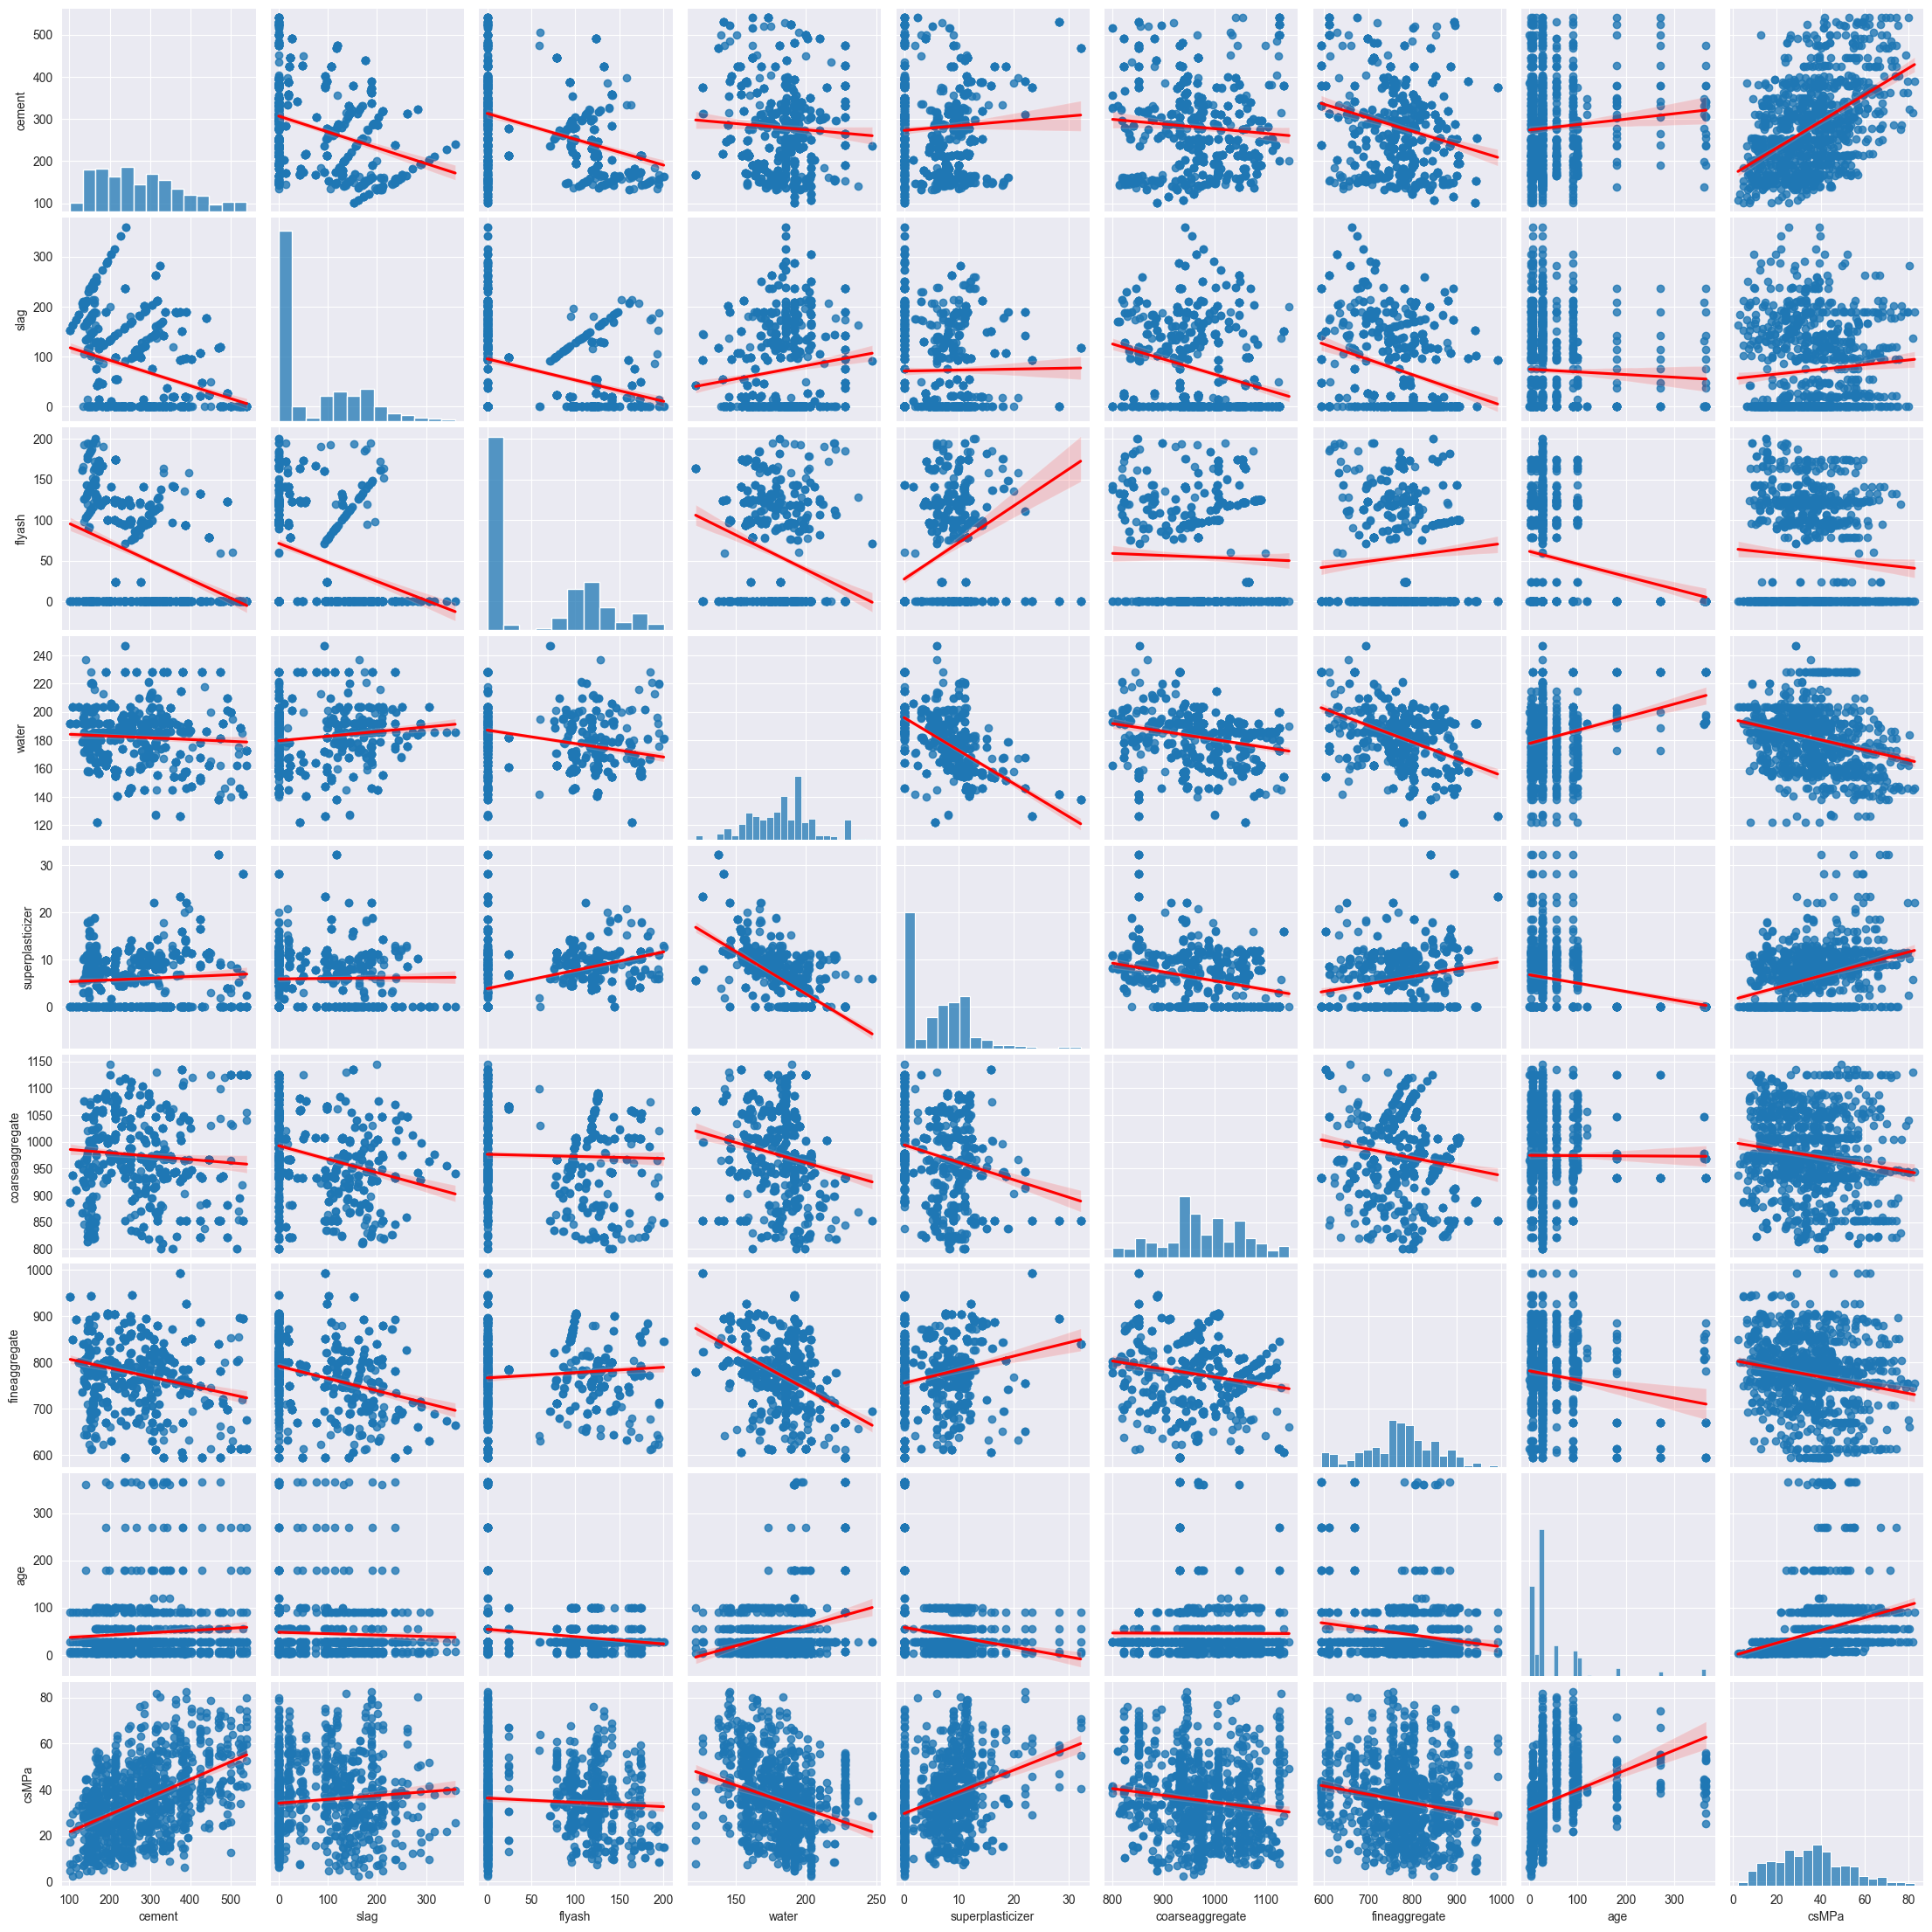

In [ ]:
sns.pairplot(data, kind = 'reg', plot_kws={'line_kws':{'color':'red'}})

**Zależności z wytrzymałością:** cement i wiek wpływają na nią dodatnio, woda — ujemnie (wyższy stosunek wodno-cementowy osłabia beton).

**Rozkłady cech:** większość składników nie ma rozkładu normalnego; żużel, popiół lotny i superplastyfikator mają wysokie słupki przy 0 — często w ogóle nie były dodawane do mieszanki.

**Relacje między składnikami:** superplastyfikator umożliwia redukcję ilości wody. Duże rozproszenie punktów na wykresach wskazuje na nieliniowy charakter zależności, co uzasadnia zastosowanie sieci neuronowej.

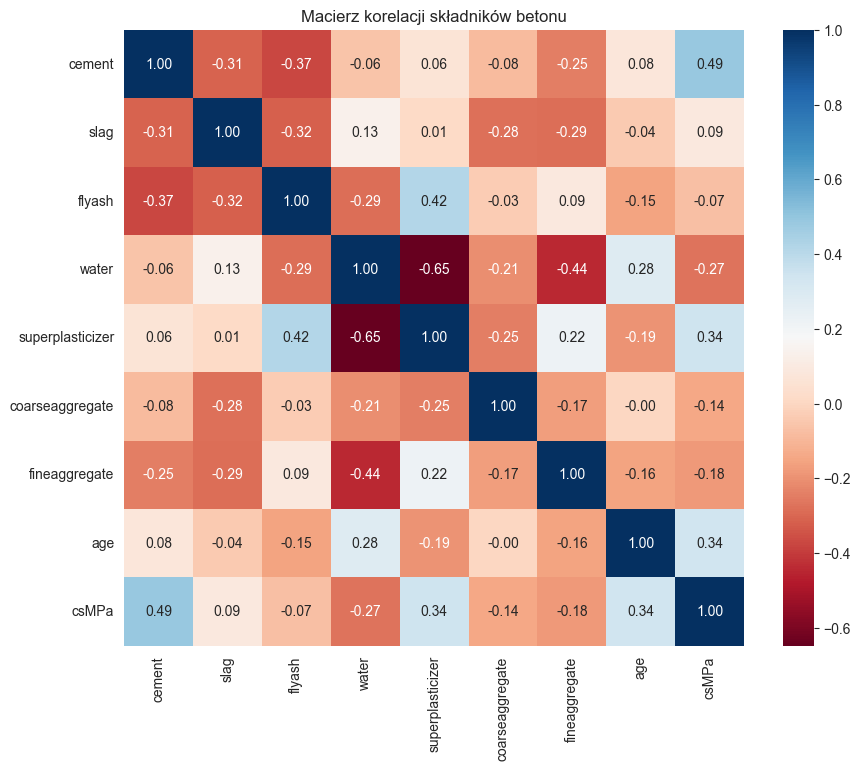

In [ ]:
correlation_matrix = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title("Macierz korelacji składników betonu")
plt.show()

**Wzrost wytrzymałości:** najsilniej wpływa cement (0.49), w mniejszym stopniu superplastyfikator i wiek betonu (oba 0.34).

**Spadek wytrzymałości:** woda (−0.27) — potwierdza zasadę, że wysoki stosunek wodno-cementowy osłabia beton.

**Zależności między składnikami:** superplastyfikator silnie koreluje ujemnie z wodą (−0.65) — stosuje się go właśnie w celu redukcji jej ilości. Popiół lotny i żużel korelują ujemnie z cementem, gdyż pełnią rolę jego częściowych zamienników w mieszance.

5. zadanie: Przygotuj dane do uczenia modelu. Podziel dane na część treningową (80% danych) i testową (20%). Dokonaj standaryzacji atrybutów w zbiorach treningowym i testowym.

In [ ]:
X = data.drop('csMPa', axis=1)
y = data['csMPa']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_y = StandardScaler()
Y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
Y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

6. zadanie: Przeprowadź próbne uczenie modelu. Skorzystaj z implementacji sieci neuronowej w Scikit-learn, PyTorch lub TensorFlow + Keras (patrz ostatnia część wykładu). Pokaż krzywą zbieżności (loss_curve). Pokaż
następujące metryki/wykresy dla danych testowych: MSE, histogram błędów, wykres Actual value vs.
Predicted value.

In [ ]:
model_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    verbose=True,
    batch_size = 10
)


model_mlp.fit(X_train_scaled, Y_train_scaled.ravel())

y_pred_scaled = model_mlp.predict(X_test_scaled)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_true = scaler_y.inverse_transform(Y_test_scaled)

print(f"Błąd MAE: {mean_absolute_error(y_true, y_pred):.2f} MPa")
print(f"Wynik R2: {r2_score(y_true, y_pred):.2f}")

Iteration 1, loss = 0.32377163
Iteration 2, loss = 0.16292277
Iteration 3, loss = 0.12403024
Iteration 4, loss = 0.09993962
Iteration 5, loss = 0.08729727
Iteration 6, loss = 0.07577629
Iteration 7, loss = 0.06977208
Iteration 8, loss = 0.06298638
Iteration 9, loss = 0.05863398
Iteration 10, loss = 0.05677402
Iteration 11, loss = 0.05276565
Iteration 12, loss = 0.04945964
Iteration 13, loss = 0.04623729
Iteration 14, loss = 0.04396433
Iteration 15, loss = 0.04152081
Iteration 16, loss = 0.04336269
Iteration 17, loss = 0.03921704
Iteration 18, loss = 0.03713090
Iteration 19, loss = 0.03592821
Iteration 20, loss = 0.03624427
Iteration 21, loss = 0.03528180
Iteration 22, loss = 0.03351414
Iteration 23, loss = 0.03344812
Iteration 24, loss = 0.03189063
Iteration 25, loss = 0.03137098
Iteration 26, loss = 0.03216067
Iteration 27, loss = 0.03158618
Iteration 28, loss = 0.02988810
Iteration 29, loss = 0.02934574
Iteration 30, loss = 0.03094847
Iteration 31, loss = 0.02971433
Iteration 32, los

**Jakość modelu (R² = 0.88):** model wyjaśnia 88% zmienności wytrzymałości betonu — bardzo dobry wynik, świadczący o skutecznym uchwyceniu nieliniowych zależności między składnikami mieszanki.

**Błąd predykcji (MAE = 3.66 MPa):** przy rozstępie wytrzymałości 10–80 MPa błąd rzędu 3.66 MPa jest praktycznie zadowalający i pozwala na precyzyjne szacowanie klasy betonu.

**Kluczowe decyzje architektoniczne:** skalowanie danych było niezbędne ze względu na duże różnice w rzędach wielkości cech. Architektura (64, 32) z ReLU okazała się wystarczająca do modelowania problemu bez przeuczenia, a mały batch size (10) ułatwił ucieczkę z lokalnych minimów podczas treningu.

Błąd MSE: 25.52


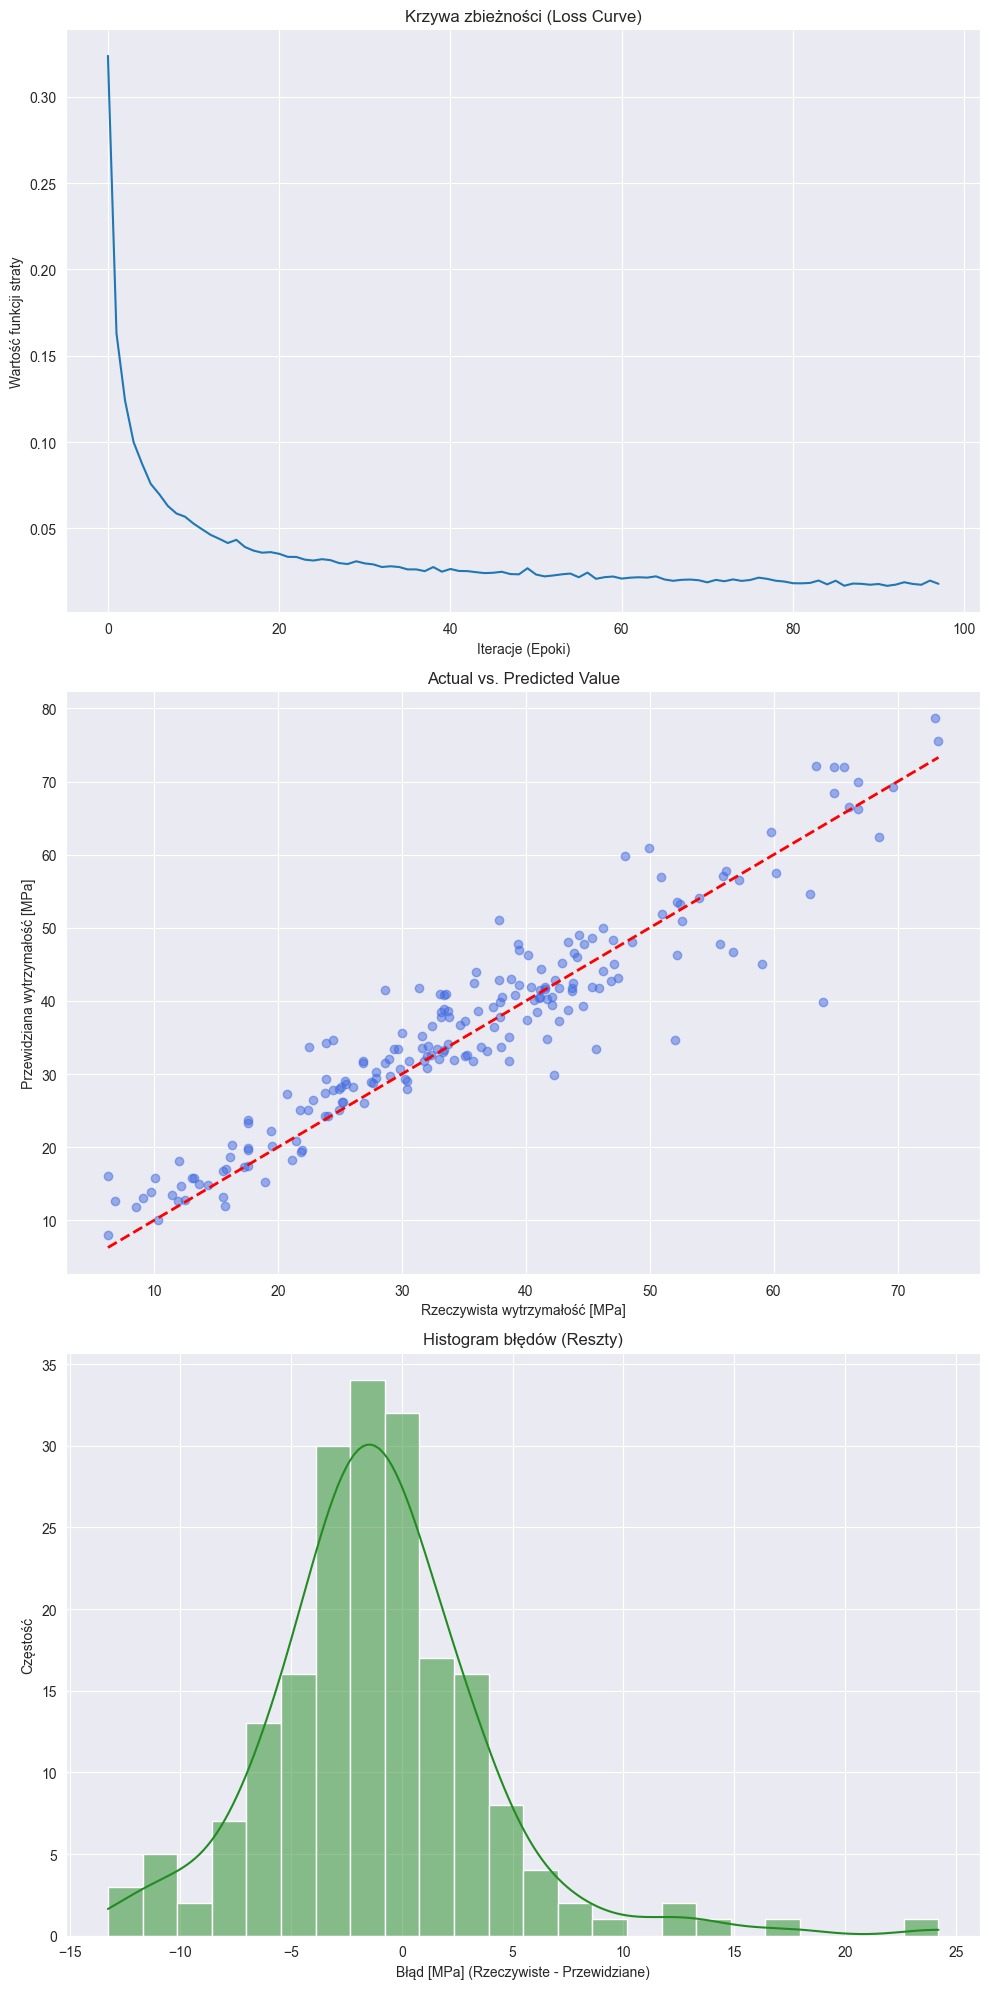

In [ ]:
mse = mean_squared_error(y_true, y_pred)
print(f"Błąd MSE: {mse:.2f}")

plt.figure(figsize=(10, 20))

plt.subplot(3, 1, 1)
plt.plot(model_mlp.loss_curve_)
plt.title('Krzywa zbieżności (Loss Curve)')
plt.xlabel('Iteracje (Epoki)')
plt.ylabel('Wartość funkcji straty')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.scatter(y_true, y_pred, alpha=0.5, color='royalblue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Value')
plt.xlabel('Rzeczywista wytrzymałość [MPa]')
plt.ylabel('Przewidziana wytrzymałość [MPa]')
plt.grid(True)

plt.subplot(3, 1, 3)
errors = y_true.flatten() - y_pred.flatten()
sns.histplot(errors, kde=True, color='forestgreen')
plt.title('Histogram błędów (Reszty)')
plt.xlabel('Błąd [MPa] (Rzeczywiste - Przewidziane)')
plt.ylabel('Częstość')
plt.grid(True)

plt.tight_layout()
plt.show()


**1. Krzywa zbieżności (Loss Curve)**

Szybki spadek straty w pierwszych 20 epokach, stabilizacja po 40. i wczesne zatrzymanie (~100 epok). Gładka krzywa potwierdza efektywny trening z optymalizatorem Adam – brak przetrenowania.

**2. Actual vs. Predicted**

Punkty tworzą wąskie pasmo wzdłuż linii idealnej (R²=0.88). Model radzi sobie równomiernie z betonami słabymi (10-30 MPa) i mocnymi (70+ MPa), bez systematycznych błędów.

**3. Histogram błędów**

Rozkład gaussowski, skupiony wokół zera (-5 do +5 MPa). Lekka asymetria (dłuższy prawy ogon) wskazuje na sporadyczne niedoszacowanie najmocniejszych próbek – bezpieczne w inżynierii budowlanej.

7. zadanie: Zoptymalizuj hiperparametry w procedurze Grid Search. Zobrazuj wyniki optymalnego modelu podobnie
jak w p. 6.

In [ ]:
parametry = {
    "hidden_layer_sizes": [(32,16), (64, 32), (128, 64)],
    "learning_rate_init": [0.001, 0.01, 0.1],
    "solver": ["adam", "lbfgs"],
    "alpha": [0.0001, 0.001, 0.01],
    "batch_size": [16, 32, 64],
}

model_mlp_test = MLPRegressor(
    random_state = 42,
    activation = 'relu',
    max_iter = 500
)

grid = GridSearchCV(
    estimator = model_mlp_test,
    param_grid = parametry,
    scoring = 'neg_mean_squared_error',
    cv = 10,
    n_jobs=-1
)
grid.fit(X_train_scaled, Y_train_scaled.ravel())
print(grid.best_params_)
print(grid.best_score_)
najlepszy_model = grid.best_estimator_

{'alpha': 0.001, 'batch_size': 32, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001, 'solver': 'adam'}
-0.08912217955628482


**Optymalna architektura (128, 64):** większa pojemność sieci okazała się konieczna do odwzorowania złożonych zależności fizyko-chemicznych betonu.

**Solver Adam, batch size 32:** Adam pokonał L-BFGS dzięki stabilnej aktualizacji wag. Wsad 32 to złoty środek między chaotycznością małych wsadów a ryzykiem utknięcia w lokalnych minimach przy dużych.

**Regularyzacja i tempo uczenia:** alpha = 0.001 zapewnia łagodną karę L2 chroniącą przed przeuczeniem; learning rate = 0.001 (wartość domyślna) okazał się optymalny — wyższe wartości powodowały przeskakiwanie minimum.

**Wynik best_score_ = −0.0891:** GridSearchCV minimalizuje błąd przez negację MSE, więc rzeczywisty MSE najlepszego modelu wynosi 0.0891 — jednak w przestrzeni przeskalowanej, nie w MPa.

8. zadanie: Wybierz jeden z atrybutów, który Twoim zdaniem pozwoli najlepiej przewidzieć wartość zmiennej
wyjściowej. Utwórz model sieci neuronowej aproksymującej zmienną wyjściową na podstawie tego
atrybutu. Porównaj wyniki p. 8 i 7.

błąd mse: 19.87


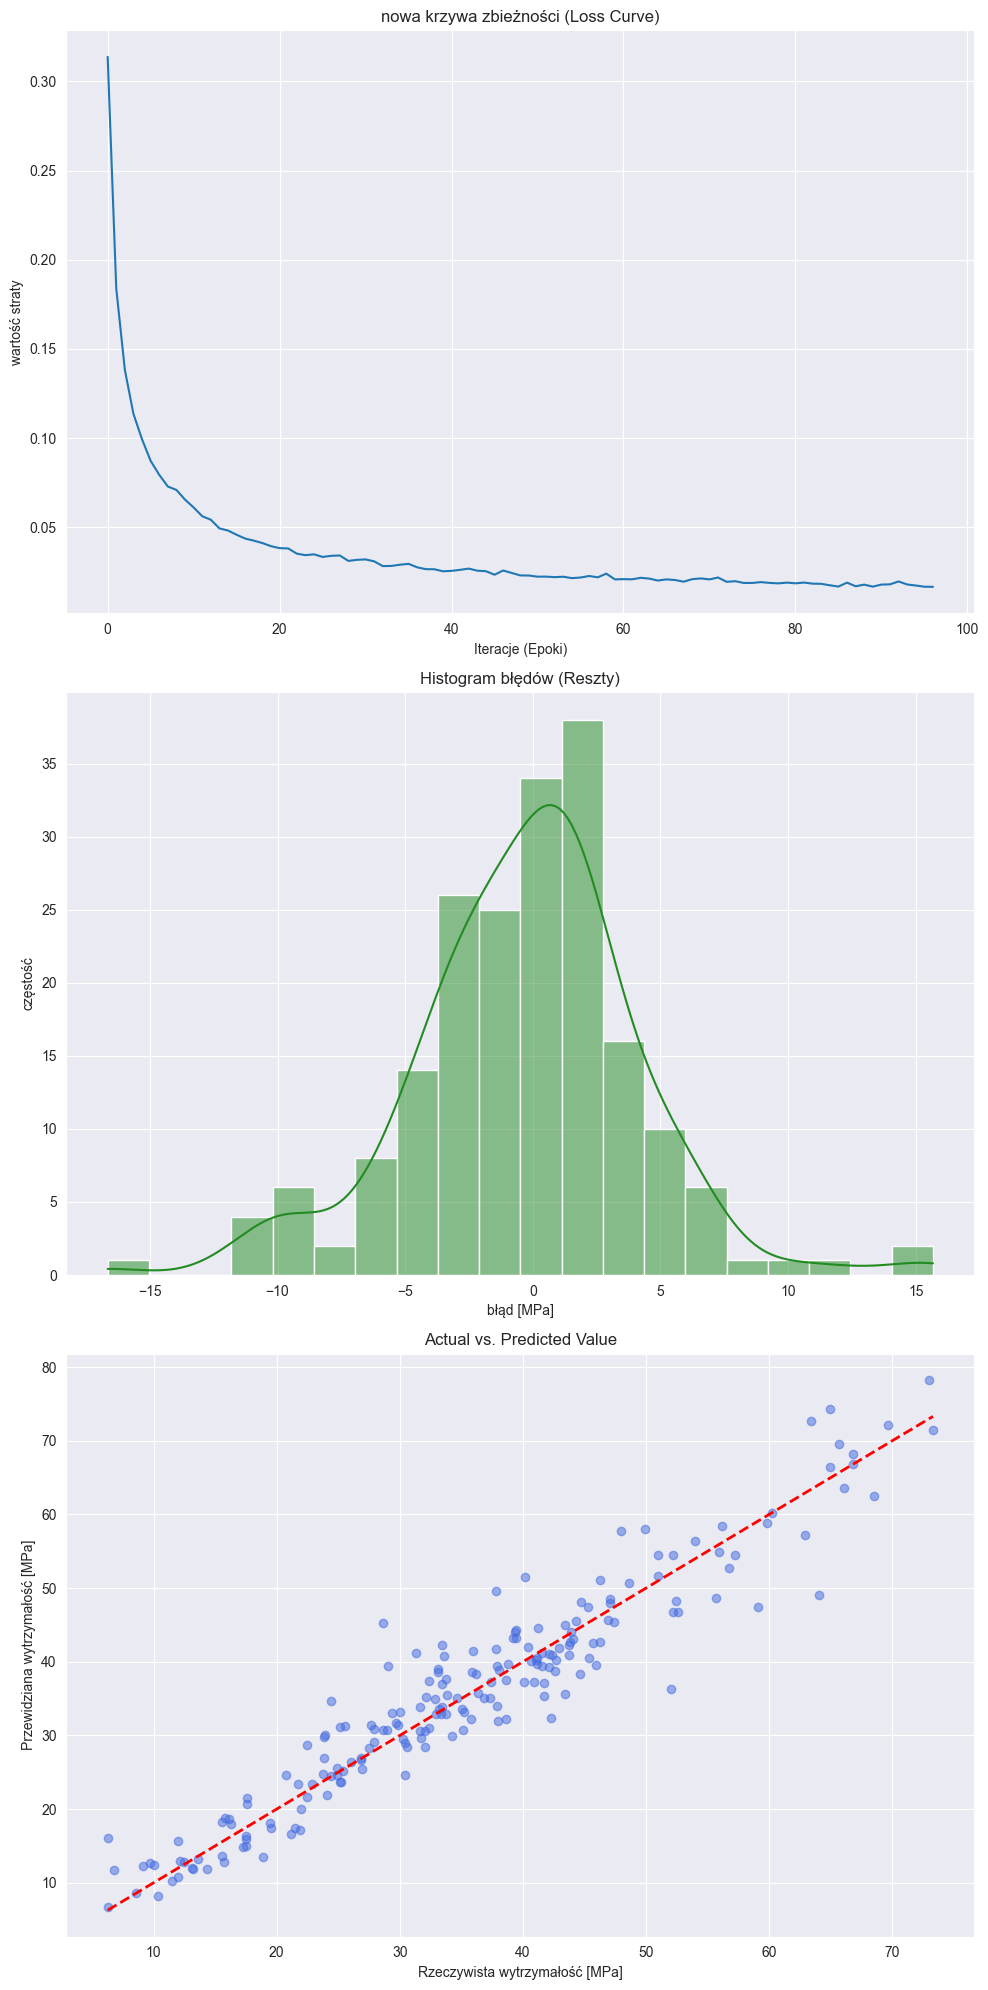

In [ ]:
y_pred_scaled_test = najlepszy_model.predict(X_test_scaled)
y_pred_test = scaler_y.inverse_transform(y_pred_scaled_test.reshape(-1, 1))
y_true_test = scaler_y.inverse_transform(Y_test_scaled)

plt.figure(figsize=(10, 20))
plt.subplot(3, 1, 1)

mse_test = mean_squared_error(y_true_test, y_pred_test)
print(f"błąd mse: {mse_test:.2f}")

plt.subplot(3, 1, 1)
plt.plot(najlepszy_model.loss_curve_)
plt.title("nowa krzywa zbieżności (Loss Curve)")
plt.xlabel('Iteracje (Epoki)')
plt.ylabel('wartość straty')
plt.grid(True)

plt.subplot(3, 1, 2)
errors_test = y_true_test.flatten() - y_pred_test.flatten()
sns.histplot(errors_test, kde=True, color='forestgreen')
plt.title('Histogram błędów (Reszty)')
plt.xlabel('błąd [MPa]')
plt.ylabel('częstość')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.scatter(y_true_test, y_pred_test, alpha=0.5, color='royalblue')
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Value')
plt.xlabel('Rzeczywista wytrzymałość [MPa]')
plt.ylabel('Przewidziana wytrzymałość [MPa]')
plt.grid(True)

plt.tight_layout()
plt.show()

* **Zauważalny spadek błędu (Większa precyzja):** Błąd średniokwadratowy (MSE) spadł z 25.52 (w pierwszym modelu) do **19.87**. To znacząca poprawa. Oznacza to, że ulepszona architektura sieci skuteczniej radzi sobie z danymi testowymi, a ogólny rozrzut pomyłek jest po prostu mniejszy.
* **Likwidacja skrajnych pomyłek (Histogram):** To najważniejsza zmiana wizualna. W poprzednim modelu (przed optymalizacją) na histogramie widać było "ogon" błędów sięgający nawet 20-25 MPa. W nowym modelu rozkład błędów jest znacznie węższy i smuklejszy. Ogromna większość pomyłek gnieździ się w bezpiecznym przedziale od -5 do 5 MPa, a skrajne wartości zostały mocno ucięte. Model stał się dużo bardziej **stabilny i godny zaufania**.
* **Ściślejsze dopasowanie (Actual vs. Predicted):** Na wykresie punktowym chmura niebieskich kropek jest teraz wyraźnie "ciaśniej" skupiona wokół czerwonej, przerywanej linii. Optymalizacja sprawiła, że model lepiej generalizuje wiedzę na nowych danych testowych i rzadziej "przestrzeliwuje" predykcje, szczególnie w środkowym zakresie wytrzymałości.

Iteration 1, loss = 0.40585611
Iteration 2, loss = 0.37952160
Iteration 3, loss = 0.37718531
Iteration 4, loss = 0.37729058
Iteration 5, loss = 0.37778992
Iteration 6, loss = 0.37520326
Iteration 7, loss = 0.37637208
Iteration 8, loss = 0.37598449
Iteration 9, loss = 0.37402508
Iteration 10, loss = 0.37379888
Iteration 11, loss = 0.37306992
Iteration 12, loss = 0.37262285
Iteration 13, loss = 0.37317415
Iteration 14, loss = 0.37298082
Iteration 15, loss = 0.37288962
Iteration 16, loss = 0.37468076
Iteration 17, loss = 0.37246870
Iteration 18, loss = 0.37389480
Iteration 19, loss = 0.37320591
Iteration 20, loss = 0.37249472
Iteration 21, loss = 0.37337791
Iteration 22, loss = 0.37641182
Iteration 23, loss = 0.37236261
Iteration 24, loss = 0.37266723
Iteration 25, loss = 0.37562714
Iteration 26, loss = 0.37346648
Iteration 27, loss = 0.37289377
Iteration 28, loss = 0.37215987
Iteration 29, loss = 0.37253156
Iteration 30, loss = 0.37237705
Iteration 31, loss = 0.37361111
Iteration 32, los

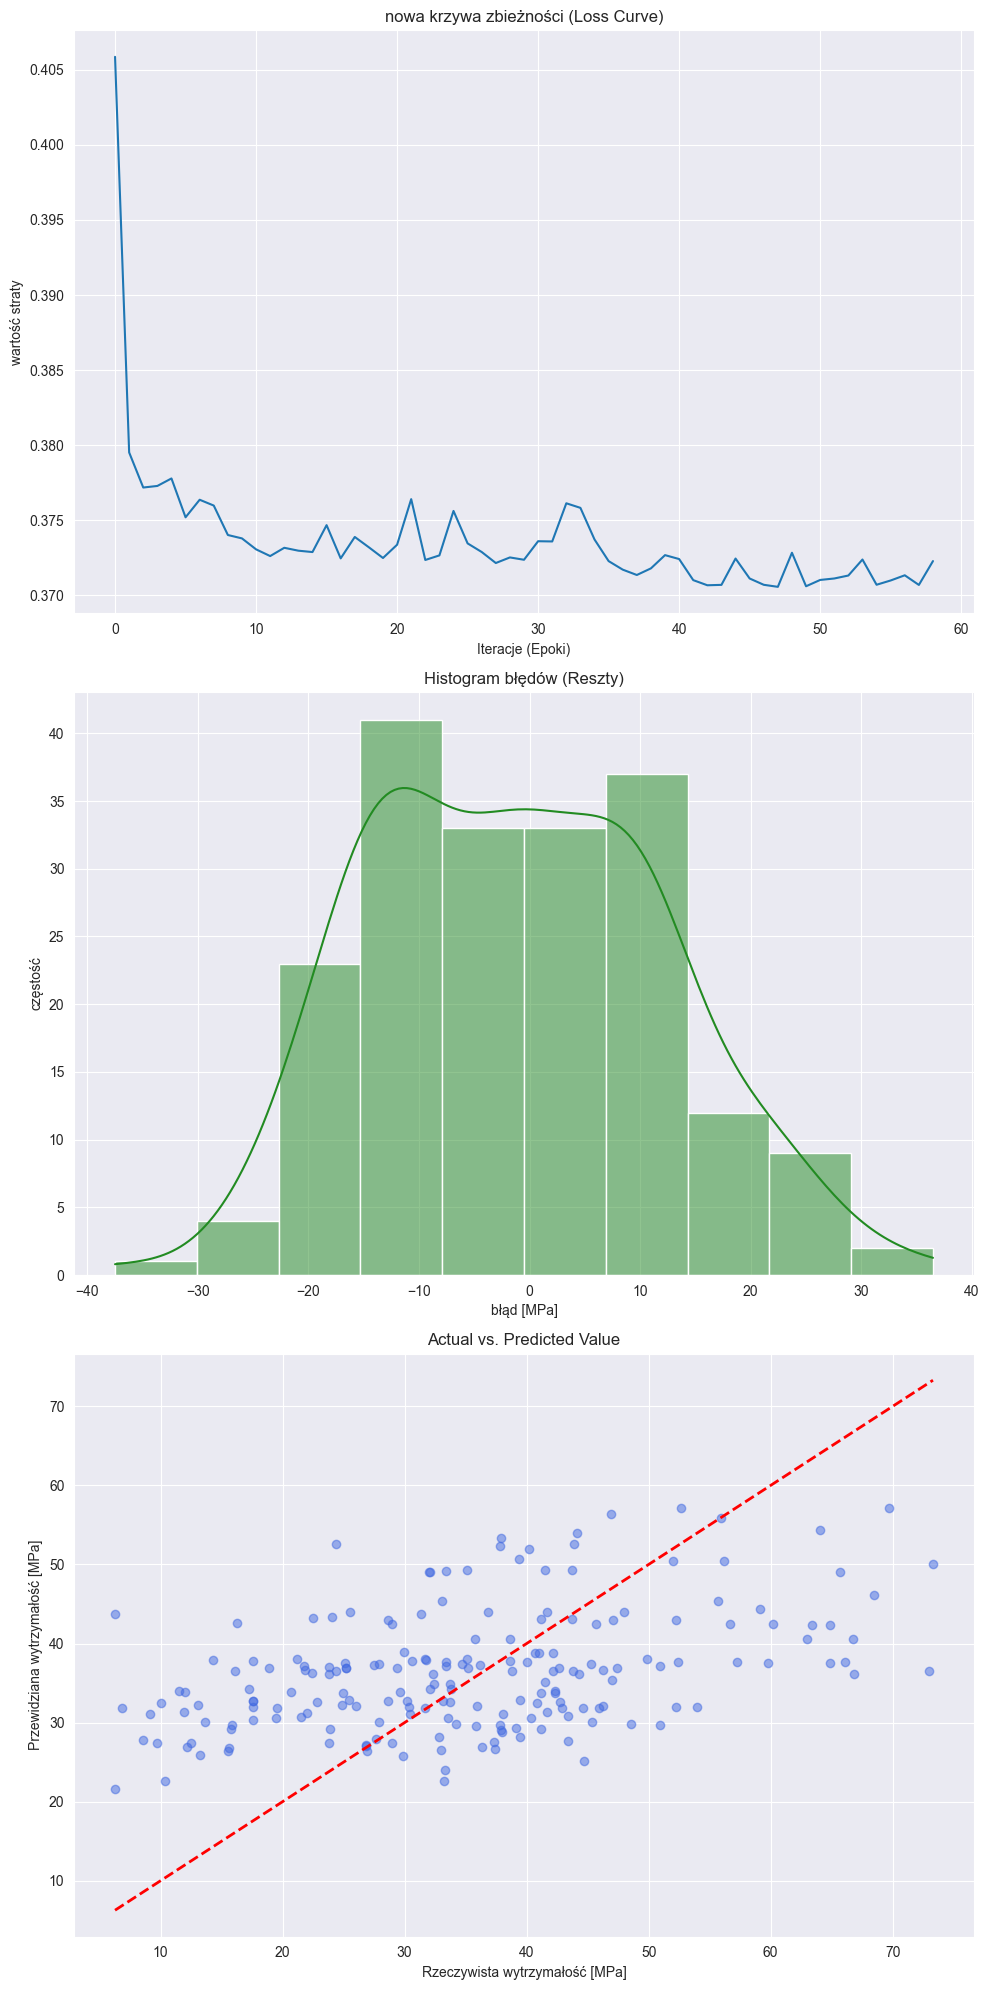

In [ ]:
x = data[['cement']]
y = data[['csMPa']]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

scaler_y = StandardScaler()
Y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
Y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


model_jedna_cecha = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    random_state = 42,
    batch_size= 32,
    alpha = 0.001,
    solver = 'adam',
    learning_rate_init = 0.001,
    max_iter = 500,
    verbose = True,
)
model_jedna_cecha.fit(x_train_scaled, Y_train_scaled.ravel())
y_pred_scaled = model_jedna_cecha.predict(x_test_scaled)

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_true = scaler_y.inverse_transform(Y_test_scaled)

plt.figure(figsize=(10, 20))
plt.subplot(3, 1, 1)

mse_jedna = mean_squared_error(y_true, y_pred)
print(f"błąd mse: {mse_jedna:.2f}")

plt.subplot(3, 1, 1)
plt.plot(model_jedna_cecha.loss_curve_)
plt.title("nowa krzywa zbieżności (Loss Curve)")
plt.xlabel('Iteracje (Epoki)')
plt.ylabel('wartość straty')
plt.grid(True)

plt.subplot(3, 1, 2)
errors_test = y_true.flatten() - y_pred.flatten()
sns.histplot(errors_test, kde=True, color='forestgreen')
plt.title('Histogram błędów (Reszty)')
plt.xlabel('błąd [MPa]')
plt.ylabel('częstość')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.scatter(y_true, y_pred, alpha=0.5, color='royalblue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Value')
plt.xlabel('Rzeczywista wytrzymałość [MPa]')
plt.ylabel('Przewidziana wytrzymałość [MPa]')
plt.grid(True)

plt.tight_layout()
plt.show()

**1. Całkowity spadek precyzji (Actual vs. Predicted)**

* **Brak podążania za czerwoną linią:** W poprzednich modelach punkty układały się wzdłuż przekątnej. Tutaj widzimy "rozmytą, poziomą chmurę".
* **Model strzela w średnią:** Niezależnie od tego, czy rzeczywista wytrzymałość betonu (oś X) wynosi 10 MPa czy 70 MPa, model niemal zawsze przewiduje wartość w przedziale od 25 do 50 MPa (oś Y).
* **Wniosek:** Sieć neuronowa zorientowała się, że na podstawie samego cementu nie potrafi dokładnie wyliczyć wytrzymałości, więc przyjęła najbezpieczniejszą strategię z matematycznego punktu widzenia: **zaczęła uśredniać wyniki**, aby minimalizować gigantyczne błędy. Zjawisko to nazywamy silnym **niedopasowaniem (underfittingiem)**.

**2. Gigantyczny rozrzut pomyłek (Histogram błędów)**
* W poprzednim, zoptymalizowanym modelu na wszystkich cechach błędy zamykały się w wąskim oknie od -5 do 5 MPa.
* Na obecnym histogramie widać, że błędy rozciągają się **od około -35 MPa do aż +35 MPa**.

**3. Słabe uczenie się (Krzywa zbieżności)**
* Chociaż krzywa spada, to wartość funkcji straty zatrzymuje się na bardzo wysokim poziomie (powyżej 0.37).
* W poprzednim eksperymencie strata spadała niemal do zera.

# D. Wnioski końcowe

**1. Wytrzymałość betonu to proces wysoce nieliniowy i wielowymiarowy**

Najważniejszym odkryciem projektu jest ostateczne potwierdzenie, że betonu nie da się opisać prostymi regułami. Eksperyment polegający na treningu modelu wyłącznie na ilości cementu zakończył się całkowitym niepowodzeniem (model zaczął uśredniać wyniki, a błędy sięgały kilkudziesięciu megapaskali). Dowodzi to, że końcowa wytrzymałość (csMPa) jest wynikiem skomplikowanej synergii wszystkich składników – przede wszystkim stosunku wody do cementu, interakcji wody z superplastyfikatorami oraz kluczowego parametru, jakim jest czas (wiek dojrzewania próbki).

**2. Sieci neuronowe (MLP) wykazują rewelacyjną skuteczność w inżynierii materiałowej**

Zastosowanie perceptronu wielowarstwowego (MLPRegressor) okazało się bardzo trafnym wyborem. Model bazowy osiągnął współczynnik determinacji na poziomie R² = 0.88, co oznacza, że sieć z sukcesem "nauczyła się" fizyko-chemicznych zależności zachodzących w mieszance betonowej, ukrytych w danych historycznych.

**3. Skalowanie danych to absolutny fundament**

Ze względu na różnice w rzędach wielkości składników (np. setki kilogramów kruszywa kontra zaledwie kilka kilogramów superplastyfikatora), zastosowanie StandardScaler było kluczowe. Bez tego kroku sieć neuronowa całkowicie zignorowałaby domieszki chemiczne, które (jak pokazała macierz korelacji) mają potężny wpływ na redukcję wody i ostateczną wytrzymałość.

**4. Optymalizacja hiperparametrów drastycznie zwiększyła bezpieczeństwo i stabilność modelu**

Proces przeszukiwania siatki (GridSearchCV) udowodnił, że domyślne parametry modelu to za mało do zastosowań inżynieryjnych. Najlepiej sprawdziła się **bardziej pojemna architektura (128 i 64 neurony)** w połączeniu z odpowiednim rozmiarem wsadu (batch_size = 32) oraz łagodną regularyzacją L2 (alpha = 0.001).
Złożoność problemu wymagała większej sieci, ale to właśnie **regularyzacja i optymalizator Adam odegrały tu główną rolę**. Ich połączone działanie nie tyle spektakularnie poprawiło samą średnią, co **zlikwidowało "wartości odstające" w pomyłkach (ucięcie długich ogonów na histogramie reszt)**. Model przestał popełniać rażące błędy (rzędu 20-25 MPa), zamykając większość pomyłek w bardzo wąskim i bezpiecznym oknie tolerancji.

# E. Literatura

1. Goodfellow, I., Bengio, Y., i Courville, A. (2016). Deep Learning. MIT Press.

2. Hastie, T., Tibshirani, R., i Friedman, J. (2009). The Elements of Statistical Learning: Data Mining, Inference, and Prediction (Wydanie 2). Springer.

3. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830.